In [49]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.preprocessing import LabelEncoder

In [51]:
PROJECT_PATH = r"C:\Users\abc\projects\Cancer Cell Classification Project"

DATA_DIR = os.path.join(PROJECT_PATH, "Data")
NOTEBOOKS_DIR = os.path.join(PROJECT_PATH, "Notebooks")
FIGURES_DIR = os.path.join(PROJECT_PATH, "Figures")

print("DATA_DIR:", DATA_DIR)
print("NOTEBOOKS_DIR:", NOTEBOOKS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

DATA_DIR: C:\Users\abc\projects\Cancer Cell Classification Project\Data
NOTEBOOKS_DIR: C:\Users\abc\projects\Cancer Cell Classification Project\Notebooks
FIGURES_DIR: C:\Users\abc\projects\Cancer Cell Classification Project\Figures


In [53]:
model_path = os.path.join(NOTEBOOKS_DIR, "best_resnet50_transfer_model.keras")
model = load_model(model_path)

print("Best ResNet50 model loaded successfully.")
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)

Best ResNet50 model loaded successfully.
Model input shape: (None, 128, 128, 3)
Model output shape: (None, 5)


In [55]:
X_test = np.load(os.path.join(DATA_DIR, "X_test.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (158, 128, 128, 3)
y_test shape: (158,)


In [57]:
df = pd.read_csv(os.path.join(DATA_DIR, "expanded_dataset.csv"))

encoder = LabelEncoder()
encoder.fit(df["moa"])

class_names = list(encoder.classes_)

print("Class names:")
for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

Class names:
0: Aurora kinase inhibitors
1: DNA damage
2: Eg5 inhibitors
3: Microtubule destabilizers
4: Microtubule stabilizers


In [59]:
image_index = 0

print("Selected image index:", image_index)
print("True label:", class_names[y_test[image_index]])

Selected image index: 0
True label: Eg5 inhibitors


In [61]:
original_img = X_test[image_index]  # original image in 0-1 range
input_img = np.expand_dims(original_img, axis=0)

# ResNet50 preprocessing
input_img_resnet = preprocess_input(input_img * 255.0)

print("Original image shape:", original_img.shape)
print("Input image shape for model:", input_img_resnet.shape)

Original image shape: (128, 128, 3)
Input image shape for model: (1, 128, 128, 3)


In [63]:
pred_probs = model.predict(input_img_resnet, verbose=0)[0]
pred_class_idx = np.argmax(pred_probs)
pred_class_name = class_names[pred_class_idx]
pred_confidence = pred_probs[pred_class_idx]

true_class_name = class_names[y_test[image_index]]

print("True class:", true_class_name)
print("Predicted class:", pred_class_name)
print(f"Prediction confidence: {pred_confidence:.4f}")

True class: Eg5 inhibitors
Predicted class: Eg5 inhibitors
Prediction confidence: 0.8317


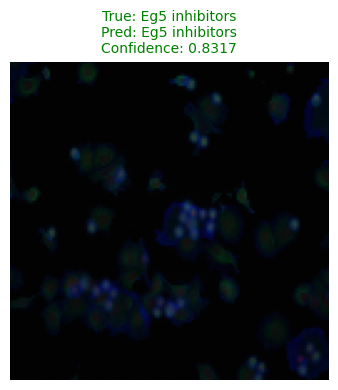

In [65]:
plt.figure(figsize=(4, 4))
plt.imshow(original_img)
plt.title(
    f"True: {true_class_name}\nPred: {pred_class_name}\nConfidence: {pred_confidence:.4f}",
    color="green" if true_class_name == pred_class_name else "red",
    fontsize=10
)
plt.axis("off")
plt.tight_layout()
plt.show()

In [67]:
for i, prob in enumerate(pred_probs):
    print(f"{class_names[i]}: {prob:.4f}")

Aurora kinase inhibitors: 0.0025
DNA damage: 0.0000
Eg5 inhibitors: 0.8317
Microtubule destabilizers: 0.0089
Microtubule stabilizers: 0.1569


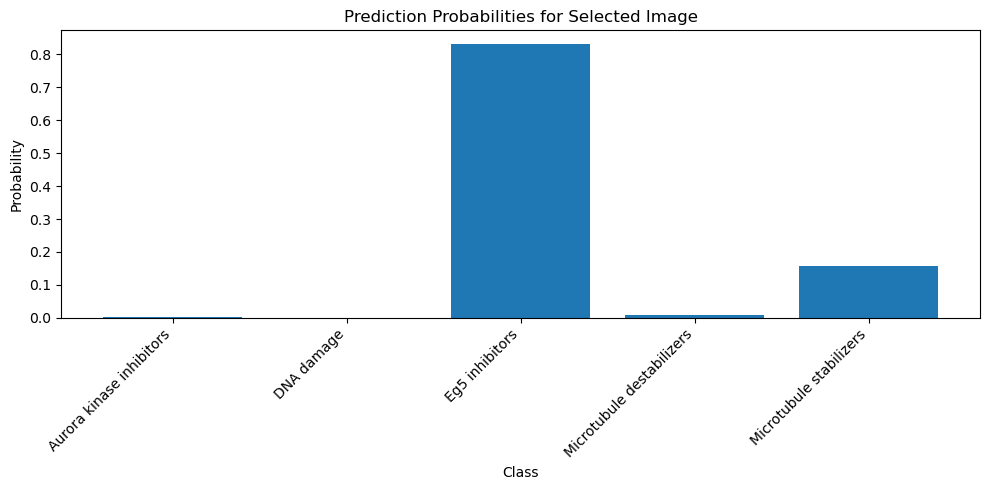

In [69]:
plt.figure(figsize=(10, 5))
plt.bar(class_names, pred_probs)
plt.title("Prediction Probabilities for Selected Image")
plt.xlabel("Class")
plt.ylabel("Probability")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

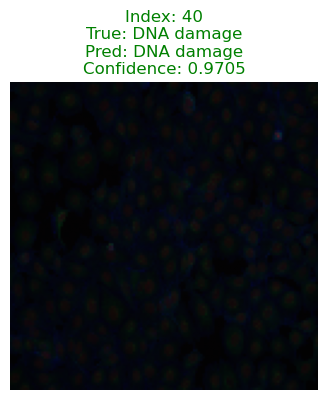

In [85]:
import random

random_index = random.randint(0, len(X_test) - 1)

original_img = X_test[random_index]
input_img = np.expand_dims(original_img, axis=0)
input_img_resnet = preprocess_input(input_img * 255.0)

pred_probs = model.predict(input_img_resnet, verbose=0)[0]
pred_class_idx = np.argmax(pred_probs)
pred_class_name = class_names[pred_class_idx]
pred_confidence = pred_probs[pred_class_idx]
true_class_name = class_names[y_test[random_index]]

plt.figure(figsize=(4, 4))
plt.imshow(original_img)
plt.title(
    f"Index: {random_index}\nTrue: {true_class_name}\nPred: {pred_class_name}\nConfidence: {pred_confidence:.4f}",
    color="green" if true_class_name == pred_class_name else "red"
)
plt.axis("off")
plt.show()